<a href="https://colab.research.google.com/github/AlexMoffatt10/COM7019/blob/main/COM7019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import os
import warnings
import json


os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [48]:
# Reproducibility
tf.keras.utils.set_random_seed(42)
tf.random.set_seed(42)
np.random.seed(42)

OUT_DIR = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

CSV_PATH = 'Stock_Price_Data_[3921].csv'

1: Loading and Exploring Data

Dataset shape: (9909, 7)
Date range: 1980-12-12 to 2020-04-01

First 5 rows:
        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3 1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4 1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400

Basic statistics:
            Open       High        Low      Close        Volume
count  9909.0000  9909.0000  9909.0000  9909.0000  9.909000e+03
mean     32.6068    32.9361    32.2776    32.6180  8.582916e+07
std      58.4158    59.0016    57.8830    58.4719  8.597195e+07
min       0.1987     0.1987     0.1964     0.1964  3.472000e+05
25%       1.0714     1.0893     1.0486     1.0714  3.304230e+07
50%       1.7293     1.7589     1.6964 

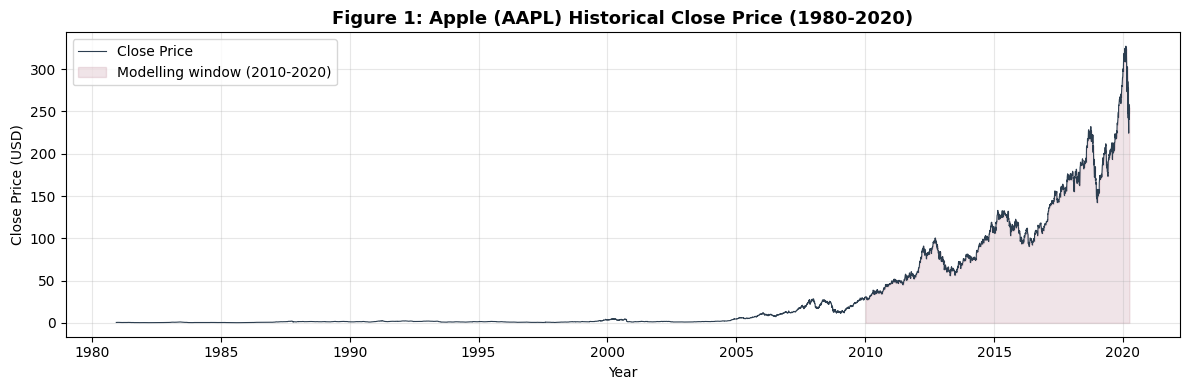

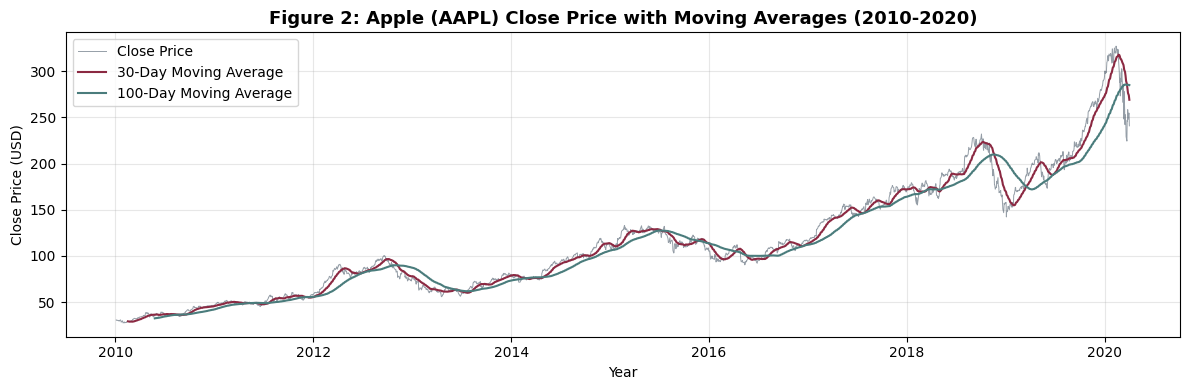

In [49]:

# 1: DATA LOADING AND EXPLORATION


print("1: Loading and Exploring Data")


df = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic statistics:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(4))
print(f"\nMissing values: {df.isnull().sum().to_dict()}")


df_model = df[df['Date'] >= '2010-01-01'].reset_index(drop=True)
print(f"\nModelling subset: {len(df_model)} rows "
      f"({df_model['Date'].min().date()} to {df_model['Date'].max().date()})")

# Figure 1:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['Date'], df['Close'], color='#2C3E50', linewidth=0.8, label='Close Price')
ax.fill_between(df_model['Date'], df_model['Close'], alpha=0.12,
                color='#8B2942', label='Modelling window (2010-2020)')
ax.set_title('Figure 1: Apple (AAPL) Historical Close Price (1980-2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Close Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig1_price_history.png', dpi=150)
plt.show()


# Figure 2:
ma30  = df_model['Close'].rolling(window=30).mean()
ma100 = df_model['Close'].rolling(window=100).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_model['Date'], df_model['Close'], color='#2C3E50',
        linewidth=0.7, alpha=0.5, label='Close Price')
ax.plot(df_model['Date'], ma30,  color='#8B2942',
        linewidth=1.5, label='30-Day Moving Average')
ax.plot(df_model['Date'], ma100, color='#4A7C7C',
        linewidth=1.5, label='100-Day Moving Average')
ax.set_title('Figure 2: Apple (AAPL) Close Price with Moving Averages (2010-2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Close Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2_moving_average.png', dpi=150)
plt.show()


In [50]:

# 2: DATA PREPROCESSING (no data leakage)



print("2: Preprocessing")


close_prices = df_model['Close'].values.reshape(-1, 1)

WINDOW_SIZE = 60
TRAIN_RATIO = 0.80

def create_sequences(data, window):

    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

total_seq_len = len(close_prices) - WINDOW_SIZE
split_idx = int(total_seq_len * TRAIN_RATIO)
train_raw = close_prices[:split_idx + WINDOW_SIZE]
test_raw  = close_prices[split_idx:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f"Train period: {df_model['Date'].iloc[0].date()} to "
      f"{df_model['Date'].iloc[split_idx + WINDOW_SIZE - 1].date()}")
print(f"Test period:  {df_model['Date'].iloc[split_idx].date()} to "
      f"{df_model['Date'].iloc[-1].date()}")
print(f"Train samples (raw): {len(train_raw)}, Test samples (raw): {len(test_raw)}")

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test  = X_test.reshape(-1, WINDOW_SIZE, 1)

print(f"\nSequence window: {WINDOW_SIZE} timesteps")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}  | y_test  shape: {y_test.shape}")


2: Preprocessing
Train period: 2010-01-04 to 2018-04-02
Test period:  2018-01-04 to 2020-04-01
Train samples (raw): 2075, Test samples (raw): 564

Sequence window: 60 timesteps
X_train shape: (2015, 60, 1) | y_train shape: (2015,)
X_test  shape: (504, 60, 1)  | y_test  shape: (504,)


In [51]:

# 3: HYPERPARAMETER TUNING



print("3: Hyperparameter Tuning (4 configurations)")


def build_model(arch, units, window, dropout, n_layers=2):
    LayerClass = LSTM if arch == 'LSTM' else GRU
    model = Sequential(name=f'{arch}_Model')
    if n_layers == 1:
        model.add(LayerClass(units, return_sequences=False,
                             input_shape=(window, 1)))
        model.add(Dropout(dropout))
    else:
        model.add(LayerClass(units, return_sequences=True,
                             input_shape=(window, 1)))
        model.add(Dropout(dropout))
        model.add(LayerClass(units // 2, return_sequences=False))
        model.add(Dropout(dropout))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def compute_metrics(true, pred, model_name):
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    print(f"\n  {model_name}: MAE={mae:.4f} | RMSE={rmse:.4f} | "
          f"R2={r2:.4f} | MAPE={mape:.2f}%")
    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
            'R2': round(r2, 4), 'MAPE': round(mape, 2)}

# Four tuning configurations varying sequence length, units, and dropout
tuning_configs = [
    {'arch': 'LSTM', 'label': 'LSTM 1', 'window': 30, 'units': 50, 'dropout': 0.2},
    {'arch': 'LSTM', 'label': 'LSTM 2', 'window': 60, 'units': 64, 'dropout': 0.3},
    {'arch': 'GRU',  'label': 'GRU 1',  'window': 30, 'units': 50, 'dropout': 0.2},
    {'arch': 'GRU',  'label': 'GRU 2',  'window': 60, 'units': 64, 'dropout': 0.3},
]

tuning_results = []
for cfg in tuning_configs:
    print(f"\nTuning: {cfg['label']} | window={cfg['window']} | "
          f"units={cfg['units']} | dropout={cfg['dropout']}")


    if cfg['window'] != WINDOW_SIZE:

        total_seq = len(close_prices) - cfg['window']
        sp = int(total_seq * TRAIN_RATIO)
        tr_raw = close_prices[:sp + cfg['window']]
        te_raw = close_prices[sp:]
        sc_tune = MinMaxScaler(feature_range=(0, 1))
        tr_sc = sc_tune.fit_transform(tr_raw)
        te_sc = sc_tune.transform(te_raw)
        Xtr, ytr = create_sequences(tr_sc, cfg['window'])
        Xte, yte = create_sequences(te_sc, cfg['window'])
        sc_use = sc_tune
    else:
        Xtr, ytr = X_train.reshape(-1, WINDOW_SIZE), y_train
        Xte, yte = X_test.reshape(-1, WINDOW_SIZE),  y_test
        sc_use = scaler

    Xtr = Xtr.reshape(-1, cfg['window'], 1)
    Xte = Xte.reshape(-1, cfg['window'], 1)

    m = build_model(cfg['arch'], cfg['units'], cfg['window'], cfg['dropout'])
    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)
    hist = m.fit(Xtr, ytr, epochs=40, batch_size=32,
                 validation_split=0.1, shuffle=False,
                 callbacks=[es], verbose=0)

    pred = sc_use.inverse_transform(
        m.predict(Xte, verbose=0).reshape(-1, 1)).flatten()
    actual_tune = sc_use.inverse_transform(yte.reshape(-1, 1)).flatten()
    metrics = compute_metrics(actual_tune, pred, cfg['label'])
    tuning_results.append({**cfg, **metrics,
                           'epochs': len(hist.history['loss'])})

print("\nTuning complete. Summary:")
print(f"\n{'Config':<8} {'Window':>8} {'Units':>6} {'Dropout':>8} "
      f"{'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'Epochs':>7}")
print("-" * 65)
for r in tuning_results:
    print(f"{r['label']:<8} {r['window']:>8} {r['units']:>6} {r['dropout']:>8} "
          f"{r['MAE']:>8} {r['RMSE']:>8} {r['MAPE']:>8} {r['epochs']:>7}")


3: Hyperparameter Tuning (4 configurations)

Tuning: LSTM 1 | window=30 | units=50 | dropout=0.2

  LSTM 1: MAE=25.4123 | RMSE=33.5356 | R2=0.3782 | MAPE=10.63%

Tuning: LSTM 2 | window=60 | units=64 | dropout=0.3

  LSTM 2: MAE=16.6735 | RMSE=22.9145 | R2=0.7092 | MAPE=6.94%

Tuning: GRU 1 | window=30 | units=50 | dropout=0.2

  GRU 1: MAE=13.0492 | RMSE=18.0004 | R2=0.8209 | MAPE=5.45%

Tuning: GRU 2 | window=60 | units=64 | dropout=0.3

  GRU 2: MAE=11.4025 | RMSE=14.3515 | R2=0.8859 | MAPE=4.93%

Tuning complete. Summary:

Config     Window  Units  Dropout      MAE     RMSE     MAPE  Epochs
-----------------------------------------------------------------
LSTM 1         30     50      0.2  25.4123  33.5356    10.63      10
LSTM 2         60     64      0.3  16.6735  22.9145     6.94       9
GRU 1          30     50      0.2  13.0492  18.0004     5.45       8
GRU 2          60     64      0.3  11.4025  14.3515     4.93      16


In [52]:

# 4: FINAL MODELS (60-step, 64/32 units)


print("4: Training Final LSTM and GRU Models")



def build_lstm_model(window_size):

    model = Sequential(name='LSTM_Model')
    model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm_model(WINDOW_SIZE)
lstm_model.summary()

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=8,
                                restore_best_weights=True, verbose=1)

print("\nTraining LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.10,
    shuffle=False,
    callbacks=[early_stop_lstm],
    verbose=1
)
lstm_epochs_run = len(lstm_history.history['loss'])
print(f"\nLSTM early-stopped at epoch {lstm_epochs_run}")

def build_gru_model(window_size):
    model = Sequential(name='GRU_Model')
    model.add(GRU(64, return_sequences=True, input_shape=(window_size, 1)))
    model.add(Dropout(0.2))
    model.add(GRU(32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

gru_model = build_gru_model(WINDOW_SIZE)
gru_model.summary()

early_stop_gru = EarlyStopping(monitor='val_loss', patience=8,
                               restore_best_weights=True, verbose=1)

print("\nTraining GRU...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.10,
    shuffle=False,
    callbacks=[early_stop_gru],
    verbose=1
)
gru_epochs_run = len(gru_history.history['loss'])
print(f"\nGRU early-stopped at epoch {gru_epochs_run}")

4: Training Final LSTM and GRU Models


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_36 (GRU)                    │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_37 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU...
Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 0.0058 - val_loss: 0.0015
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0150 - val_loss: 0.0035
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0024 - val_loss: 5.3830e-04
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.0029 - val_loss: 0.0013
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0018 - val_loss: 4.5277e-04
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 8/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 9/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0019 - val_loss: 9.9343e-04
Epoch 10/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 11/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0010 - val_loss: 6.9788e-04
Epoch 12/80
57/57 ━━━━━━━━━━

5: Predictions and Evaluation

 Final Model Metrics

  LSTM (Final): MAE=7.4925 | RMSE=10.0025 | R2=0.9446 | MAPE=3.23%

  GRU  (Final): MAE=8.9810 | RMSE=12.2506 | R2=0.9169 | MAPE=3.79%

  Persistence Baseline: MAE=3.1600 | RMSE=5.1021 | R2=0.9856 | MAPE=1.45%


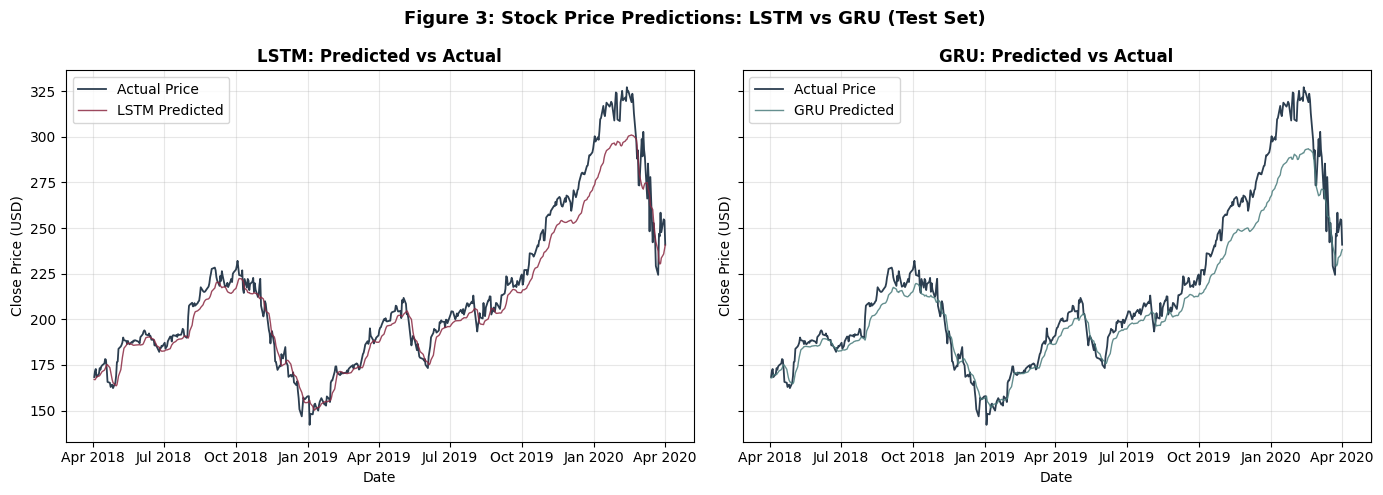

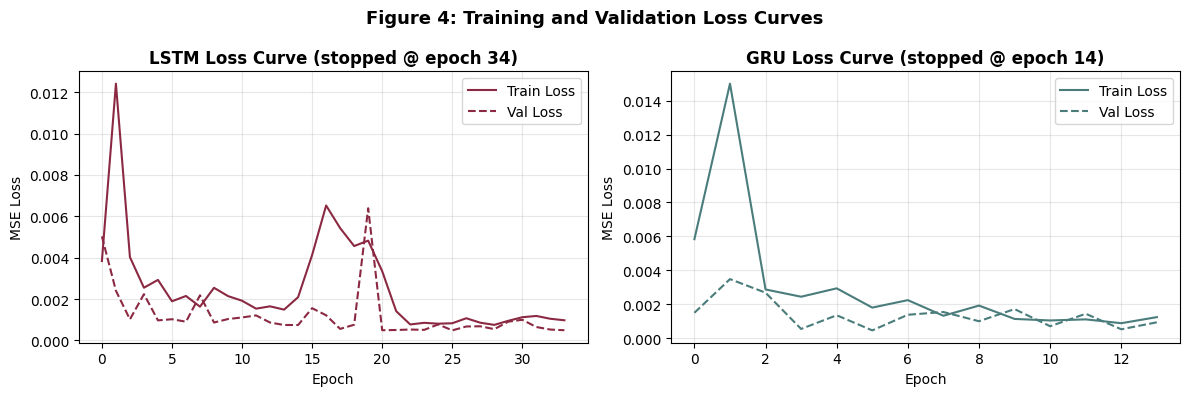

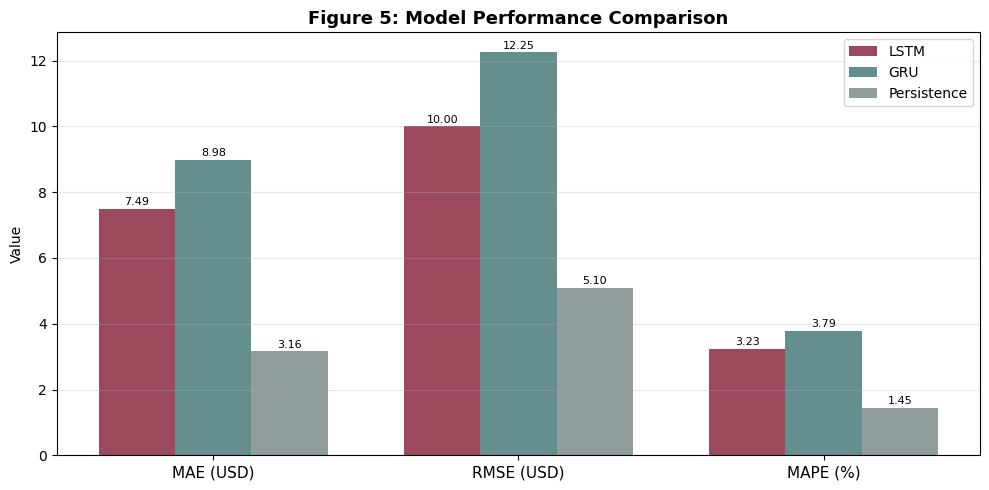

In [57]:

# 5: PREDICTIONS AND EVALUATION

print("5: Predictions and Evaluation")


lstm_pred = scaler.inverse_transform(
    lstm_model.predict(X_test, verbose=0).reshape(-1, 1)).flatten()
gru_pred = scaler.inverse_transform(
    gru_model.predict(X_test, verbose=0).reshape(-1, 1)).flatten()
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

persistence_pred = actual[:-1]
actual_pers      = actual[1:]

print("\n Final Model Metrics")
lstm_metrics = compute_metrics(actual, lstm_pred, "LSTM (Final)")
gru_metrics  = compute_metrics(actual, gru_pred,  "GRU  (Final)")
pers_metrics = compute_metrics(actual_pers, persistence_pred, "Persistence Baseline")

# Figure 3: Predicted vs Actual
test_dates = df_model['Date'].values[
    (len(close_prices) - len(test_raw)) + WINDOW_SIZE:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, pred, name, col in zip(
        axes,
        [lstm_pred, gru_pred],
        ['LSTM', 'GRU'],
        ['#8B2942', '#4A7C7C']):
    ax.plot(test_dates, actual, label='Actual Price',
            color='#2C3E50', linewidth=1.3)
    ax.plot(test_dates, pred, label=f'{name} Predicted',
            color=col, linewidth=1.0, alpha=0.85)
    ax.set_title(f'{name}: Predicted vs Actual', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Figure 3: Stock Price Predictions: LSTM vs GRU (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig3_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


# Figure 4: Training / Validation Loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name, col in zip(
        axes,
        [lstm_history, gru_history],
        ['LSTM', 'GRU'],
        ['#8B2942', '#4A7C7C']):
    ax.plot(hist.history['loss'], label='Train Loss',
            color=col, linewidth=1.5)
    ax.plot(hist.history['val_loss'], label='Val Loss',
            color=col, linewidth=1.5, linestyle='--')
    stopped = len(hist.history['loss'])
    ax.set_title(f'{name} Loss Curve (stopped @ epoch {stopped})',
                 fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Figure 4: Training and Validation Loss Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig4_loss_curves.png', dpi=150)
plt.show()


# Figure 5: Metrics Bar Chart (LSTM vs GRU vs Persistence)
metric_labels = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)']
lstm_vals = [lstm_metrics['MAE'], lstm_metrics['RMSE'], lstm_metrics['MAPE']]
gru_vals  = [gru_metrics['MAE'],  gru_metrics['RMSE'],  gru_metrics['MAPE']]
pers_vals = [pers_metrics['MAE'], pers_metrics['RMSE'], pers_metrics['MAPE']]

x = np.arange(len(metric_labels))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w, lstm_vals, w, label='LSTM',        color='#8B2942', alpha=0.85)
bars2 = ax.bar(x,     gru_vals,  w, label='GRU',         color='#4A7C7C', alpha=0.85)
bars3 = ax.bar(x + w, pers_vals, w, label='Persistence', color='#7F8C8D', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Value')
ax.set_title('Figure 5: Model Performance Comparison',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5_metrics_comparison.png', dpi=150)
plt.show()


In [58]:

# 6: FINAL SUMMARY

print("6: Final Summary")

print(f"\n{'Metric':<12} {'LSTM':>10} {'GRU':>10} {'Persistence':>13} {'Winner':>8}")
print("-" * 57)
for m in ['MAE', 'RMSE', 'MAPE']:
    vals = [lstm_metrics[m], gru_metrics[m], pers_metrics[m]]
    winner = ['LSTM', 'GRU', 'Persistence'][vals.index(min(vals))]
    print(f"{m:<12} {lstm_metrics[m]:>10} {gru_metrics[m]:>10} "
          f"{pers_metrics[m]:>13} {winner:>8}")
r2_vals = [lstm_metrics['R2'], gru_metrics['R2'], pers_metrics['R2']]
r2_winner = ['LSTM', 'GRU', 'Persistence'][r2_vals.index(max(r2_vals))]
print(f"{'R2':<12} {lstm_metrics['R2']:>10} {gru_metrics['R2']:>10} "
      f"{pers_metrics['R2']:>13} {r2_winner:>8}")

winner = 'GRU' if gru_metrics['RMSE'] < lstm_metrics['RMSE'] else 'LSTM'
print(f"\n Recommended model: {winner} ")


results = {
    'lstm': lstm_metrics,
    'gru': gru_metrics,
    'persistence': pers_metrics,
    'lstm_epochs': lstm_epochs_run,
    'gru_epochs': gru_epochs_run,
    'tuning': tuning_results,
    'window_size': WINDOW_SIZE,
    'train_ratio': TRAIN_RATIO
}
with open(f'{OUT_DIR}/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nAll done.")

6: Final Summary

Metric             LSTM        GRU   Persistence   Winner
---------------------------------------------------------
MAE              7.4925      8.981          3.16 Persistence
RMSE            10.0025    12.2506        5.1021 Persistence
MAPE               3.23       3.79          1.45 Persistence
R2               0.9446     0.9169        0.9856 Persistence

 Recommended model: LSTM 

All done.
